# Simulating FRB Populations with astropath

This notebook demonstrates how to use the `astropath.simulations.generate_frbs` module to generate synthetic FRB populations with realistic properties for different surveys (CHIME, DSA, ASKAP).

The generated FRBs have the following properties:
- **DM**: Extragalactic dispersion measure (pc/cm³)
- **z**: Redshift
- **M_r**: Host galaxy absolute r-band magnitude
- **m_r**: Host galaxy apparent r-band magnitude

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
from astropath.simulations import generate_frbs, SURVEY_GRIDS

## Available Surveys

The module supports several FRB surveys, each with its own P(z,DM) grid that captures the selection effects and sensitivity of that instrument.

In [3]:
print("Available surveys:")
for survey in SURVEY_GRIDS.keys():
    print(f"  - {survey}")

Available surveys:
  - CHIME
  - DSA
  - ASKAP
  - CRAFT
  - CRAFT_ICS_1300
  - CRAFT_ICS_892
  - CRAFT_ICS_1632
  - Parkes
  - FAST


## Basic Usage: Generate FRBs for a Single Survey

The simplest usage generates FRBs by sampling from the survey-specific P(z,DM) grid.

In [4]:
# Generate 1000 CHIME FRBs with a fixed seed for reproducibility
df_chime = generate_frbs(1000, 'CHIME', seed=42)

print(f"Generated {len(df_chime)} CHIME FRBs")
df_chime.head(10)

/home/xavier/Projects/FRB/FRB/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Generated 1000 CHIME FRBs


,DM,z,M_r,m_r
0,445.0,0.25,-20.668179,19.903369
1,1175.0,1.38,-17.186789,27.835079
2,710.0,0.63,-18.888494,24.042910
3,585.0,0.45,-19.627295,22.426597
4,215.0,0.11,-21.673259,16.935208
5,215.0,0.11,-21.673391,16.935076
6,225.0,0.05,-22.359913,14.447599
7,850.0,0.94,-18.013236,25.981079
8,1225.0,0.45,-19.614478,22.439414
9,930.0,0.59,-19.028381,23.730532


In [5]:
# Summary statistics
df_chime.describe()

,DM,z,M_r,m_r
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,599.490000,0.472650,-20.029199,21.093989
std,476.539431,0.435738,1.625707,4.181865
min,30.000000,0.010000,-23.447827,9.801139
25%,280.000000,0.160000,-21.276191,18.214361
50%,470.000000,0.350000,-20.125226,21.286513
75%,770.000000,0.650000,-18.815323,24.198472
max,4455.000000,3.760000,-15.238038,32.423546


## Comparing Different Surveys

Different surveys have different selection functions, leading to different redshift and DM distributions. Let's compare CHIME, DSA, and ASKAP.

In [6]:
# Generate FRBs for three major surveys
n_frbs = 5000
seed = 42

df_chime = generate_frbs(n_frbs, 'CHIME', seed=seed)
df_dsa = generate_frbs(n_frbs, 'DSA', seed=seed)
df_askap = generate_frbs(n_frbs, 'ASKAP', seed=seed)

surveys = {
    'CHIME': df_chime,
    'DSA': df_dsa,
    'ASKAP': df_askap
}

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/DSA_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CRAFT_class_I_and_II_pzdm.npz


In [7]:
# Compare summary statistics
print("Survey Comparison Summary")
print("=" * 60)
for name, df in surveys.items():
    print(f"\n{name}:")
    print(f"  DM:  median = {df['DM'].median():.0f}, range = [{df['DM'].min():.0f}, {df['DM'].max():.0f}] pc/cm³")
    print(f"  z:   median = {df['z'].median():.3f}, range = [{df['z'].min():.3f}, {df['z'].max():.3f}]")
    print(f"  m_r: median = {df['m_r'].median():.1f}, range = [{df['m_r'].min():.1f}, {df['m_r'].max():.1f}]")

Survey Comparison Summary

CHIME:
  DM:  median = 485, range = [10, 5850] pc/cm³
  z:   median = 0.350, range = [0.010, 3.760]
  m_r: median = 21.3, range = [9.1, 32.4]

DSA:
  DM:  median = 520, range = [10, 6040] pc/cm³
  z:   median = 0.400, range = [0.010, 4.400]
  m_r: median = 21.6, range = [9.1, 32.8]

ASKAP:
  DM:  median = 265, range = [10, 6055] pc/cm³
  z:   median = 0.130, range = [0.010, 1.060]
  m_r: median = 18.9, range = [9.1, 29.1]


### Redshift Distributions

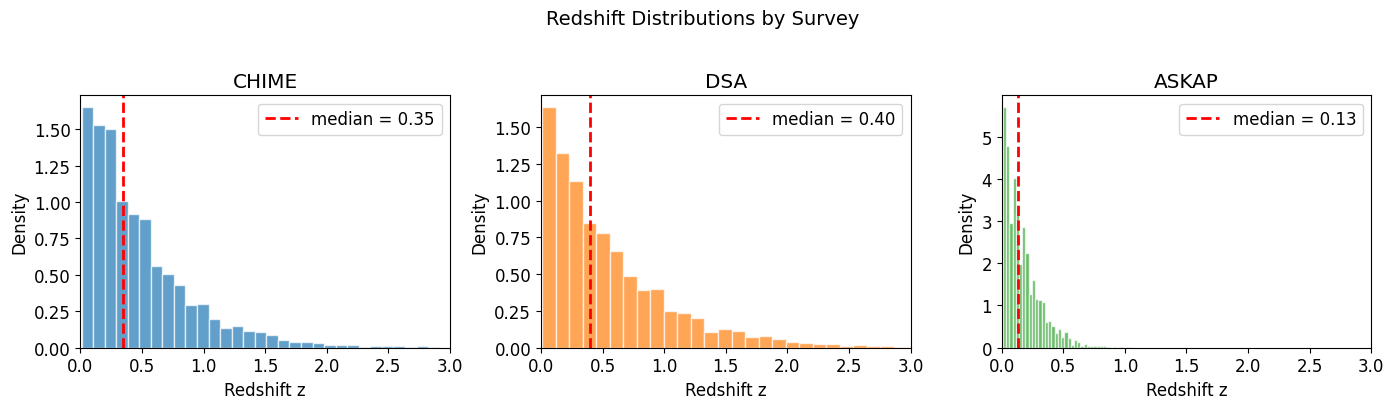

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, (name, df), color in zip(axes, surveys.items(), colors):
    ax.hist(df['z'], bins=40, alpha=0.7, color=color, density=True, edgecolor='white')
    ax.axvline(df['z'].median(), color='red', linestyle='--', linewidth=2, label=f'median = {df["z"].median():.2f}')
    ax.set_xlabel('Redshift z')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}')
    ax.legend()
    ax.set_xlim(0, 3)

plt.suptitle('Redshift Distributions by Survey', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### DM Distributions

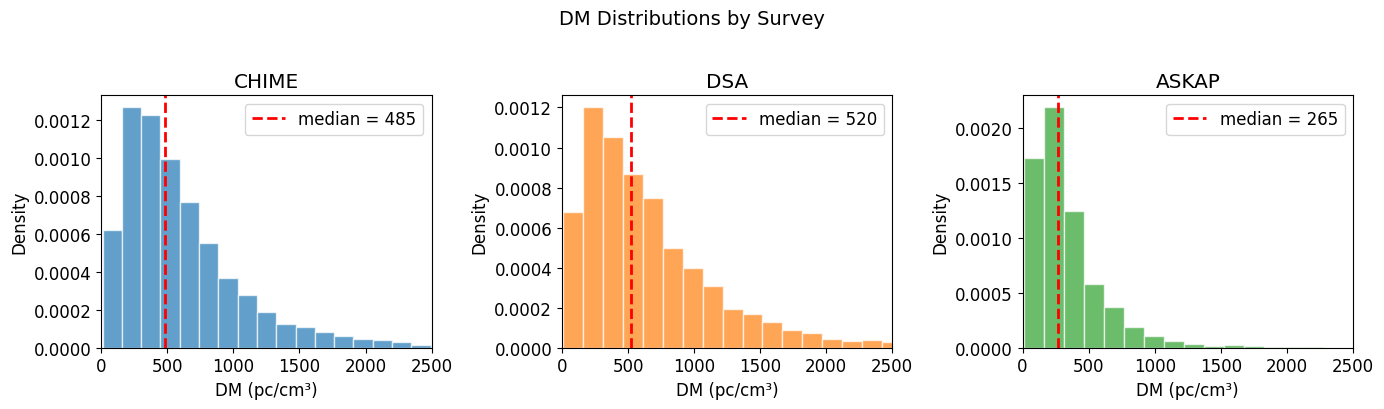

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df), color in zip(axes, surveys.items(), colors):
    ax.hist(df['DM'], bins=40, alpha=0.7, color=color, density=True, edgecolor='white')
    ax.axvline(df['DM'].median(), color='red', linestyle='--', linewidth=2, label=f'median = {df["DM"].median():.0f}')
    ax.set_xlabel('DM (pc/cm³)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}')
    ax.legend()
    ax.set_xlim(0, 2500)

plt.suptitle('DM Distributions by Survey', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### DM vs Redshift

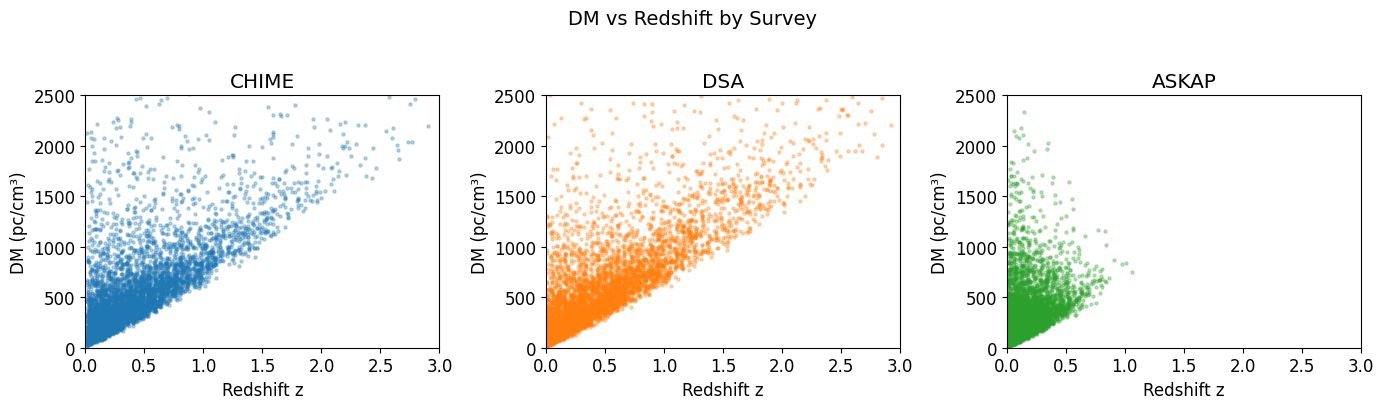

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df), color in zip(axes, surveys.items(), colors):
    ax.scatter(df['z'], df['DM'], alpha=0.3, s=5, color=color)
    ax.set_xlabel('Redshift z')
    ax.set_ylabel('DM (pc/cm³)')
    ax.set_title(f'{name}')
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 2500)

plt.suptitle('DM vs Redshift by Survey', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Apparent Magnitude Distributions

The apparent magnitude of the host galaxy depends on both the absolute magnitude (M_r) and the redshift.

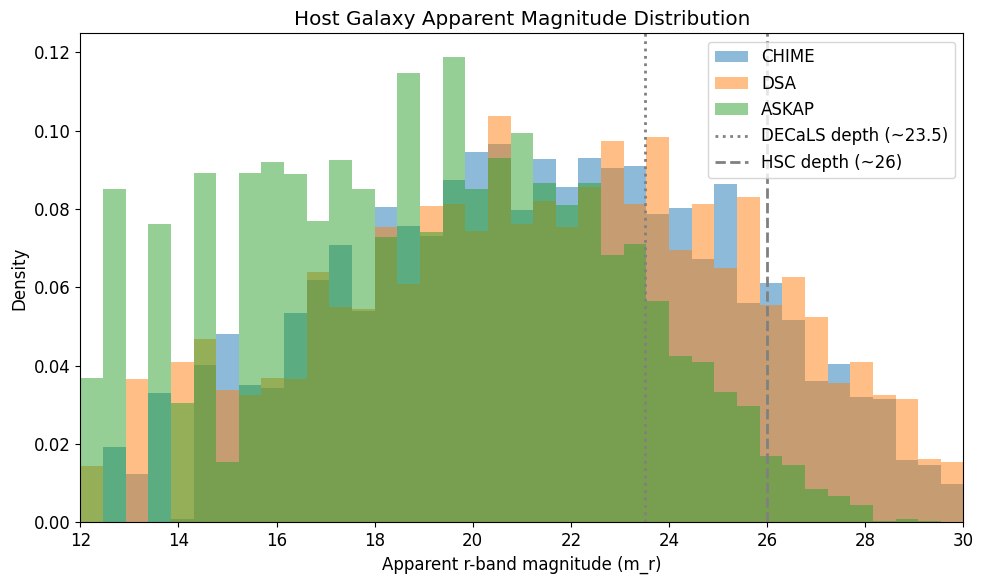

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(12, 30, 40)
for (name, df), color in zip(surveys.items(), colors):
    ax.hist(df['m_r'], bins=bins, alpha=0.5, color=color, label=name, density=True)

# Add typical survey depth limits
ax.axvline(23.5, color='gray', linestyle=':', linewidth=2, label='DECaLS depth (~23.5)')
ax.axvline(26, color='gray', linestyle='--', linewidth=2, label='HSC depth (~26)')

ax.set_xlabel('Apparent r-band magnitude (m_r)')
ax.set_ylabel('Density')
ax.set_title('Host Galaxy Apparent Magnitude Distribution')
ax.legend()
ax.set_xlim(12, 30)
plt.tight_layout()
plt.show()

## Using an Observed DM Catalog

If you have observed DM values from a specific sample, you can use them to constrain the DM distribution via kernel density estimation. This is useful when you want to simulate FRBs that match a specific observed population.

In [12]:
# Example: DMs from DSA-110 observations (Connor+24)
dsa_observed_dms = np.array([
    561.50, 186.30, 335.40, 371.00, 415.90, 429.50, 586.80, 312.40,
    213.90, 597.00, 572.70, 1019.50, 576.40, 275.10, 387.80, 405.30,
    1347.10, 359.50, 319.70, 508.30, 662.30, 552.10, 789.50, 571.30,
    406.90, 1204.10, 412.00, 306.00, 547.80, 591.50, 395.10, 356.50,
    441.30, 445.20, 1371.70, 317.30, 501.50, 453.20, 723.60
])

print(f"Observed DSA DMs: N={len(dsa_observed_dms)}, median={np.median(dsa_observed_dms):.0f} pc/cm³")

Observed DSA DMs: N=39, median=445 pc/cm³


In [13]:
# Generate FRBs using the observed DM distribution
df_dsa_from_catalog = generate_frbs(5000, 'DSA', dm_catalog=dsa_observed_dms, seed=42)

# Compare with default sampling
df_dsa_default = generate_frbs(5000, 'DSA', seed=42)

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/DSA_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/DSA_pzdm.npz


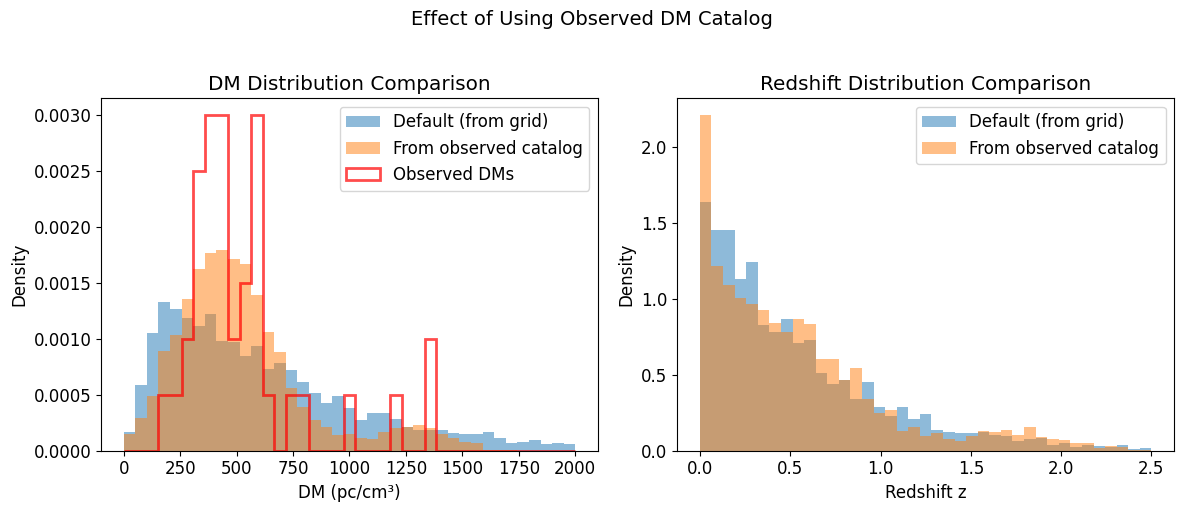

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DM comparison
ax = axes[0]
bins = np.linspace(0, 2000, 40)
ax.hist(df_dsa_default['DM'], bins=bins, alpha=0.5, label='Default (from grid)', density=True)
ax.hist(df_dsa_from_catalog['DM'], bins=bins, alpha=0.5, label='From observed catalog', density=True)
ax.hist(dsa_observed_dms, bins=bins, alpha=0.7, histtype='step', linewidth=2, 
        color='red', label='Observed DMs', density=True)
ax.set_xlabel('DM (pc/cm³)')
ax.set_ylabel('Density')
ax.set_title('DM Distribution Comparison')
ax.legend()

# Redshift comparison
ax = axes[1]
bins = np.linspace(0, 2.5, 40)
ax.hist(df_dsa_default['z'], bins=bins, alpha=0.5, label='Default (from grid)', density=True)
ax.hist(df_dsa_from_catalog['z'], bins=bins, alpha=0.5, label='From observed catalog', density=True)
ax.set_xlabel('Redshift z')
ax.set_ylabel('Density')
ax.set_title('Redshift Distribution Comparison')
ax.legend()

plt.suptitle('Effect of Using Observed DM Catalog', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Reproducibility

Using the `seed` parameter ensures reproducible results.

In [15]:
# Generate two sets with the same seed
df1 = generate_frbs(100, 'CHIME', seed=12345)
df2 = generate_frbs(100, 'CHIME', seed=12345)

# Verify they are identical
print("Are the two DataFrames identical?")
print(f"  DM:  {np.allclose(df1['DM'], df2['DM'])}")
print(f"  z:   {np.allclose(df1['z'], df2['z'])}")
print(f"  M_r: {np.allclose(df1['M_r'], df2['M_r'])}")
print(f"  m_r: {np.allclose(df1['m_r'], df2['m_r'])}")

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Are the two DataFrames identical?
  DM:  True
  z:   True
  M_r: True
  m_r: True


## Using a Custom Cosmology

By default, the module uses Planck18 cosmology. You can specify a different cosmology for the distance modulus calculations.

In [16]:
from astropy.cosmology import WMAP9, Planck18

# Compare apparent magnitudes with different cosmologies
df_planck = generate_frbs(1000, 'CHIME', cosmo=Planck18, seed=42)
df_wmap = generate_frbs(1000, 'CHIME', cosmo=WMAP9, seed=42)

# The DM, z, and M_r will be the same, but m_r will differ slightly
print("Comparison of apparent magnitudes with different cosmologies:")
print(f"  Planck18 median m_r: {df_planck['m_r'].median():.3f}")
print(f"  WMAP9 median m_r:    {df_wmap['m_r'].median():.3f}")
print(f"  Difference:          {(df_planck['m_r'].median() - df_wmap['m_r'].median()):.4f} mag")

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Comparison of apparent magnitudes with different cosmologies:
  Planck18 median m_r: 21.287
  WMAP9 median m_r:    21.247
  Difference:          0.0392 mag


## Calculating Detection Fractions

One common use case is to estimate what fraction of FRB hosts would be detectable given a survey magnitude limit.

In [17]:
# Survey depth limits
mag_limits = {
    'Pan-STARRS': 23.2,
    'DECaLS': 23.5,
    'HSC-Wide': 26.0,
    'HSC-Deep': 27.0,
}

print("Fraction of FRB hosts detectable by survey depth:")
print("=" * 65)
print(f"{'Survey':<15} {'Limit':<8} {'CHIME':<12} {'DSA':<12} {'ASKAP':<12}")
print("-" * 65)

for survey_name, mag_limit in mag_limits.items():
    fracs = []
    for df in [df_chime, df_dsa, df_askap]:
        frac = (df['m_r'] < mag_limit).mean() * 100
        fracs.append(f"{frac:.1f}%")
    print(f"{survey_name:<15} {mag_limit:<8.1f} {fracs[0]:<12} {fracs[1]:<12} {fracs[2]:<12}")

Fraction of FRB hosts detectable by survey depth:
Survey          Limit    CHIME        DSA          ASKAP       
-----------------------------------------------------------------
Pan-STARRS      23.2     66.8%        63.3%        86.2%       
DECaLS          23.5     69.3%        65.9%        88.3%       
HSC-Wide        26.0     87.0%        84.3%        98.0%       
HSC-Deep        27.0     92.1%        90.1%        99.3%       


## Saving Generated FRBs

You can save the generated FRB population to various formats for later use.

In [18]:
# Generate a sample population
df_sample = generate_frbs(10000, 'CHIME', seed=42)

# Save to different formats
# df_sample.to_csv('simulated_chime_frbs.csv', index=False)
# df_sample.to_parquet('simulated_chime_frbs.parquet', index=False)

print("Example of saving to CSV:")
print("  df_sample.to_csv('simulated_chime_frbs.csv', index=False)")
print("\nExample of saving to Parquet:")
print("  df_sample.to_parquet('simulated_chime_frbs.parquet', index=False)")

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Example of saving to CSV:
  df_sample.to_csv('simulated_chime_frbs.csv', index=False)

Example of saving to Parquet:
  df_sample.to_parquet('simulated_chime_frbs.parquet', index=False)


## Summary

The `generate_frbs()` function provides a simple interface for generating realistic FRB populations:

1. **Basic usage**: `generate_frbs(n_frbs, survey)` - samples from survey-specific P(z,DM) grids
2. **Custom DM distribution**: Use `dm_catalog` to sample DMs from observed values
3. **Reproducibility**: Use `seed` for reproducible results
4. **Custom cosmology**: Use `cosmo` to specify a different cosmology

The generated populations can be used for:
- Testing PATH analysis pipelines
- Estimating host galaxy detection fractions
- Studying selection effects across surveys
- Planning observations